In [80]:
# Cell 1 — Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

In [81]:
df = pd.read_csv('nyc_bus_cleaned.csv')

In [82]:
df_B41 = df[df['PublishedLineName'] == 'B41'].copy()

In [83]:
df_B41['RecordedAtTime'] = pd.to_datetime(df_B41['RecordedAtTime'])
df_B41['ExpectedArrivalTime'] = pd.to_datetime(df_B41['ExpectedArrivalTime'])
df_B41['Scheduled_dt'] = pd.to_datetime(df_B41['Scheduled_dt'])

In [84]:
df_B41 = df_B41[df_B41['Scheduled_dt'].dt.month == 6]
print(f"Rows after June filter: {len(df_B41):,}")
print(f"Date range: {df_B41['Scheduled_dt'].min()} → {df_B41['Scheduled_dt'].max()}")

Rows after June filter: 91,771
Date range: 2017-06-01 00:00:00 → 2017-06-30 23:54:00


In [85]:
print(f"Total B41 rows: {len(df_B41):,}")
print(f"Directions: {df_B41['DirectionRef'].unique()}")
print(f"Unique next stops: {df_B41['NextStopPointName'].nunique()}")
df_B41.head(3)

Total B41 rows: 91,771
Directions: [1. 0.]
Unique next stops: 85


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime,Scheduled_dt,delay_minutes
388,2017-06-01 00:03:31,1.0,B41,CADMAN PLAZA WEST/JOHNSON ST,40.695534,-73.990829,KINGS PLAZA via FLATBSH,40.609211,-73.921516,NYCT_4602,40.649097,-73.958392,FLATBUSH AV/ALBEMARLE RD,< 1 stop away,215.0,2017-06-01 00:04:41,00:05:22,2017-06-01 00:05:22,-0.683333
439,2017-06-01 00:03:42,0.0,B41,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,DNTWN BKLYN CADMAN PLZ via FLATBSH,40.695408,-73.990784,NYCT_4621,40.692423,-73.990166,JORALEMON ST/COURT ST,approaching,46.0,2017-06-01 00:03:57,00:03:31,2017-06-01 00:03:31,0.433333
622,2017-06-01 00:03:36,0.0,B41,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,DNTWN BKLYN CADMAN PLZ via FLATBSH,40.695408,-73.990784,NYCT_4595,40.632267,-73.947073,FLATBUSH AV/NOSTRAND AV,approaching,68.0,2017-06-01 00:03:56,00:00:00,2017-06-01 00:00:00,3.933333


In [86]:
# Cell 3 — Estimate stop coordinates using median vehicle location
# Each row = a bus reporting it is approaching NextStopPointName
# Median of VehicleLocation gives a robust estimate of the stop position

stop_coords = (
    df_B41
    .groupby(['PublishedLineName', 'DirectionRef', 'NextStopPointName'])
    .agg(
        stop_lat=('VehicleLocation.Latitude',  'median'),
        stop_lon=('VehicleLocation.Longitude', 'median'),
        obs     =('VehicleLocation.Latitude',  'count')
    )
    .reset_index()
    .rename(columns={'NextStopPointName': 'stop_key'})
)

print(f"Stop coordinate table shape: {stop_coords.shape}")
print(f"Stops per direction:")
print(stop_coords.groupby('DirectionRef')['stop_key'].count())
stop_coords.head(10)

Stop coordinate table shape: (103, 6)
Stops per direction:
DirectionRef
0.0    51
1.0    52
Name: stop_key, dtype: int64


,PublishedLineName,DirectionRef,stop_key,stop_lat,stop_lon,obs
0,B41,0.0,AV N/E 46 ST,40.618791,-73.929455,180
1,B41,0.0,AV N/E 48 ST,40.618902,-73.927686,119
2,B41,0.0,AV N/E 53 ST,40.619148,-73.923701,182
3,B41,0.0,AV N/E 55 ST,40.619279,-73.921577,189
4,B41,0.0,AV N/E 57 ST,40.619419,-73.919304,327
5,B41,0.0,AV N/UTICA AV,40.618973,-73.926504,211
6,B41,0.0,CADMAN PLZ W/MONTAGUE ST,40.693387,-73.990570,1382
7,B41,0.0,FLATBUSH AV/ATLANTIC AV,40.683600,-73.977115,2231
8,B41,0.0,FLATBUSH AV/AV D,40.639415,-73.954563,664
9,B41,0.0,FLATBUSH AV/AV I,40.629007,-73.943624,324


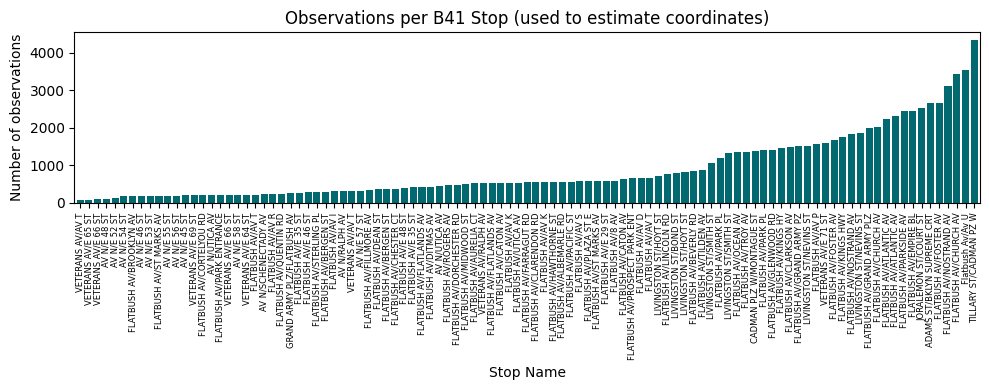


Stops with < 10 observations (potentially unreliable):
Empty DataFrame
Columns: [stop_key, DirectionRef, obs]
Index: []


In [87]:
# Cell 4 — Sanity check: how many observations back each stop estimate?
# Low obs count = unreliable median estimate

fig, ax = plt.subplots(figsize=(10, 4))
stop_coords.sort_values('obs').plot.bar(
    x='stop_key', y='obs', ax=ax, legend=False, color='#01696f', width=0.8
)
ax.set_title('Observations per B41 Stop (used to estimate coordinates)')
ax.set_xlabel('Stop Name')
ax.set_ylabel('Number of observations')
ax.tick_params(axis='x', labelsize=6, rotation=90)
plt.tight_layout()
plt.savefig('fig_stop_obs_count.png', dpi=150)
plt.show()

# Flag stops with very few observations
low_obs = stop_coords[stop_coords['obs'] < 10]
print(f"\nStops with < 10 observations (potentially unreliable):")
print(low_obs[['stop_key','DirectionRef','obs']])

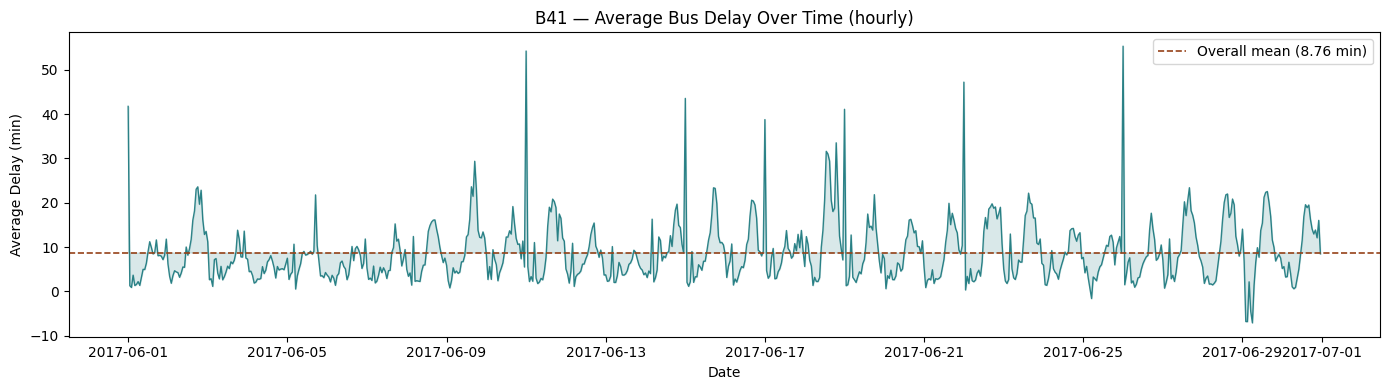

In [88]:
# Cell 4b — Time series plot of average delay over time
delay_ts = (
    df_B41
    .set_index('Scheduled_dt')
    .resample('h')['delay_minutes']
    .mean()
    .dropna()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(delay_ts.index, delay_ts.values,
        color='#01696f', lw=1, alpha=0.8)
ax.axhline(delay_ts.mean(), color='#964219', lw=1.2, ls='--',
           label=f'Overall mean ({delay_ts.mean():.2f} min)')
ax.fill_between(delay_ts.index, delay_ts.values,
                delay_ts.mean(), alpha=0.15, color='#01696f')
ax.set(xlabel='Date', ylabel='Average Delay (min)',
       title='B41 — Average Bus Delay Over Time (hourly)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_02_delay_timeseries.png', dpi=150)
plt.show()

In [90]:
# Cell 5 — Add exact Origin and Destination coordinates
# These are known precisely from the dataset — no need to estimate

origins = (
    df_B41[['PublishedLineName', 'DirectionRef', 'OriginName', 'OriginLat', 'OriginLong']]
    .drop_duplicates()
    .rename(columns={'OriginName':'stop_key','OriginLat':'stop_lat','OriginLong':'stop_lon'})
    .assign(obs=np.nan, stop_type='origin')
)

destinations = (
    df_B41[['PublishedLineName', 'DirectionRef', 'DestinationName', 'DestinationLat', 'DestinationLong']]
    .drop_duplicates()
    .rename(columns={'DestinationName':'stop_key','DestinationLat':'stop_lat','DestinationLong':'stop_lon'})
    .assign(obs=np.nan, stop_type='destination')
)

stop_coords['stop_type'] = 'intermediate'

# Combine all stops
all_stops = pd.concat([origins, destinations, stop_coords], ignore_index=True)

print(f"Total stops (origin + intermediate + destination): {len(all_stops)}")
print(all_stops['stop_type'].value_counts())
all_stops.head()

Total stops (origin + intermediate + destination): 122
stop_type
intermediate    103
destination      10
origin            9
Name: count, dtype: int64


,PublishedLineName,DirectionRef,stop_key,stop_lat,stop_lon,obs,stop_type
0,B41,1.0,CADMAN PLAZA WEST/JOHNSON ST,40.695534,-73.990829,NaN,origin
1,B41,0.0,FLATBUSH AV/KINGS PLAZA,40.609253,-73.921539,NaN,origin
2,B41,0.0,E 70 ST/VETERANS AV,40.619934,-73.908707,NaN,origin
3,B41,1.0,FLATBUSH AV/OCEAN AV,40.662643,-73.962143,NaN,origin
4,B41,0.0,FLATBUSH AV/TROY AV,40.619526,-73.933342,NaN,origin


In [91]:
# Cell 6 — Interactive map of B41 stop locations
# Color: green = origin, red = destination, blue = intermediate

color_map = {'origin': 'green', 'destination': 'red', 'intermediate': 'blue'}

m = folium.Map(
    location=[all_stops['stop_lat'].median(), all_stops['stop_lon'].median()],
    zoom_start=13
)

for _, row in all_stops.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=5,
        color=color_map.get(row['stop_type'], 'blue'),
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['stop_key']}</b><br>"
            f"Type: {row['stop_type']}<br>"
            f"Dir: {row['DirectionRef']}<br>"
            f"Obs: {row['obs']}",
            max_width=200
        )
    ).add_to(m)

m.save('b41_stop_map.html')
print("Map saved as b41_stop_map.html — open in browser to inspect")
m   # displays inline in Jupyter

Map saved as b41_stop_map.html — open in browser to inspect


In [92]:
# Cell 7 — Save the final stop coordinates table
all_stops.to_csv('b41_stop_coords.csv', index=False)
print("Saved: b41_stop_coords.csv")
print(all_stops.shape)
all_stops.tail()

Saved: b41_stop_coords.csv
(122, 7)


,PublishedLineName,DirectionRef,stop_key,stop_lat,stop_lon,obs,stop_type
117,B41,1.0,VETERANS AV/AV T,40.619847,-73.912226,80.0,intermediate
118,B41,1.0,VETERANS AV/E 64 ST,40.619622,-73.916117,218.0,intermediate
119,B41,1.0,VETERANS AV/E 66 ST,40.619751,-73.913914,100.0,intermediate
120,B41,1.0,VETERANS AV/E 69 ST,40.619884,-73.911567,207.0,intermediate
121,B41,1.0,VETERANS AV/E 71 ST,40.620104,-73.908248,1600.0,intermediate


In [93]:
df_B41 = df_B41.merge(
    stop_coords[['stop_key','DirectionRef','stop_lat','stop_lon']],
    left_on=['NextStopPointName','DirectionRef'],
    right_on=['stop_key','DirectionRef'],
    how='left'
)

In [94]:
# Check how many rows got coordinates
matched = df_B41['stop_lat'].notna().sum()
total   = len(df_B41)
print(f"Matched: {matched:,} / {total:,} rows ({matched/total*100:.1f}%)")
df_B41[['NextStopPointName', 'stop_lat', 'stop_lon', 'delay_minutes']].head(5)

Matched: 91,771 / 91,771 rows (100.0%)


,NextStopPointName,stop_lat,stop_lon,delay_minutes
0,FLATBUSH AV/ALBEMARLE RD,40.648339,-73.958222,-0.683333
1,JORALEMON ST/COURT ST,40.691279,-73.989000,0.433333
2,FLATBUSH AV/NOSTRAND AV,40.631540,-73.946305,3.933333
3,FLATBUSH AV/8 AV,40.676827,-73.972203,7.700000
4,FLATBUSH AV/FLATLANDS AV,40.621631,-73.935820,8.533333


In [95]:
# Cell 9 — Parse timestamps, clean delay column

# Remove extreme outliers (operational anomalies: > 60 min late or early)
before = len(df_B41)
df_B41 = df_B41[(df_B41['delay_minutes'] > -60) & (df_B41['delay_minutes'] < 60)]
df_B41 = df_B41.dropna(subset=['delay_minutes', 'stop_lat', 'stop_lon'])
print(f"Rows removed: {before - len(df_B41):,}  |  Remaining: {len(df_B41):,}")
print(df_B41['delay_minutes'].describe())

Rows removed: 561  |  Remaining: 91,210
count    91210.000000
mean         9.523601
std         11.976642
min        -39.800000
25%          1.550000
50%          5.916667
75%         14.000000
max         59.983333
Name: delay_minutes, dtype: float64


In [96]:
# Cell 10 — Feature engineering for QR model
# Temporal features from scheduled arrival time
df_B41['hour']        = df_B41['Scheduled_dt'].dt.hour
df_B41['day_of_week'] = df_B41['Scheduled_dt'].dt.dayofweek
df_B41['is_weekend']  = (df_B41['day_of_week'] >= 5).astype(int)
df_B41['is_peak']     = (
    ((df_B41['hour'] >= 7)  & (df_B41['hour'] <= 9)) |
    ((df_B41['hour'] >= 16) & (df_B41['hour'] <= 19))
).astype(int)

# Distance from stop (uncertainty horizon proxy)
df_B41['DistanceFromStop'] = pd.to_numeric(df_B41['DistanceFromStop'], errors='coerce').fillna(0)

# Upstream delay: lag delay within same vehicle trip
df_B41 = df_B41.sort_values(['VehicleRef', 'Scheduled_dt'])
df_B41['upstream_delay'] = (
    df_B41.groupby('VehicleRef')['delay_minutes']
          .shift(1)
          .fillna(0)
)

print("Features created. Sample:")
df_B41[['hour','is_peak','is_weekend','DistanceFromStop',
        'stop_lat','stop_lon','upstream_delay','delay_minutes']].head(5)

Features created. Sample:


,hour,is_peak,is_weekend,DistanceFromStop,stop_lat,stop_lon,upstream_delay,delay_minutes
3570,7,1,0,152.0,40.619715,-73.914518,0.000000,2.500000
3600,7,1,0,23.0,40.619087,-73.933007,2.500000,3.183333
3630,7,1,0,622.0,40.637571,-73.952704,3.183333,2.300000
3660,7,1,0,470.0,40.654444,-73.959620,2.300000,3.116667
3692,7,1,0,34.0,40.662105,-73.961717,3.116667,7.166667


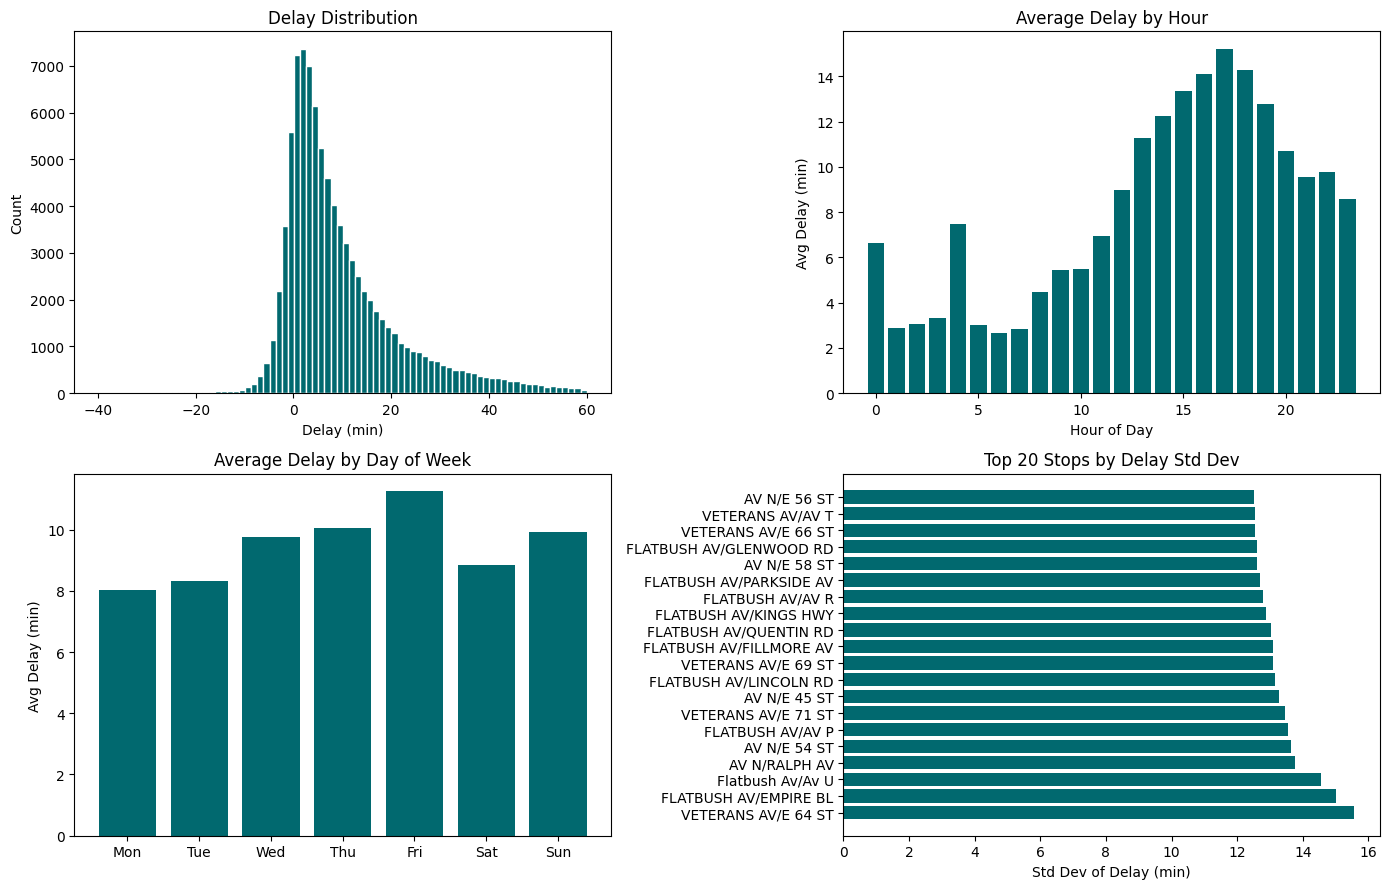

In [97]:
# Cell 11 — EDA: key delay patterns across time and stops
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Delay distribution
axes[0,0].hist(df_B41['delay_minutes'], bins=80, color='#01696f', edgecolor='white')
axes[0,0].set(title='Delay Distribution', xlabel='Delay (min)', ylabel='Count')

# 2. Average delay by hour
hourly = df_B41.groupby('hour')['delay_minutes'].mean()
axes[0,1].bar(hourly.index, hourly.values, color='#01696f')
axes[0,1].set(title='Average Delay by Hour', xlabel='Hour of Day', ylabel='Avg Delay (min)')

# 3. Average delay by day of week
daily = df_B41.groupby('day_of_week')['delay_minutes'].mean()
axes[1,0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], daily.values, color='#01696f')
axes[1,0].set(title='Average Delay by Day of Week', ylabel='Avg Delay (min)')

# 4. Delay variance by stop (heteroscedasticity visual)
stop_var = (df_B41.groupby('NextStopPointName')['delay_minutes']
                  .std()
                  .sort_values(ascending=False)
                  .head(20))
axes[1,1].barh(stop_var.index, stop_var.values, color='#01696f')
axes[1,1].set(title='Top 20 Stops by Delay Std Dev',
              xlabel='Std Dev of Delay (min)')

plt.tight_layout()
plt.savefig('fig_02_eda_delay.png', dpi=150)
plt.show()

In [98]:
# Cell 12 — Formally test for heteroscedasticity before applying QR
# We use a temporary OLS model; the residuals are what we test
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Temporary simple OLS: predict delay from key features
bp_features = ['DistanceFromStop', 'is_peak', 'upstream_delay', 'hour']
X_bp = sm.add_constant(df_B41[bp_features].dropna())
y_bp = df_B41.loc[X_bp.index, 'delay_minutes']

ols_temp = sm.OLS(y_bp, X_bp).fit()
bp_stat, bp_p, _, _ = het_breuschpagan(ols_temp.resid, X_bp)

print(f"Breusch-Pagan statistic : {bp_stat:.3f}")
print(f"p-value                 : {bp_p:.6f}")

if bp_p < 0.05:
    print("\n✓ HETEROSCEDASTICITY CONFIRMED (p < 0.05)")
    print("  Variance of delay is NOT constant across conditions.")
    print("  → Quantile Regression is the correct approach.")
else:
    print("\nNo significant heteroscedasticity detected.")

Breusch-Pagan statistic : 8120.456
p-value                 : 0.000000

✓ HETEROSCEDASTICITY CONFIRMED (p < 0.05)
  Variance of delay is NOT constant across conditions.
  → Quantile Regression is the correct approach.


In [112]:
# Cell 12b — Time-based train/test split (no shuffling for time series)
df_B41 = df_B41.sort_values('Scheduled_dt').reset_index(drop=True)

cutoff = int(len(df_B41) * 0.8)
df_train = df_B41.iloc[:cutoff].copy()
df_test  = df_B41.iloc[cutoff:].copy()

print(f"Train: {len(df_train):,} rows")
print(f"Test:  {len(df_test):,} rows")
print(f"Train period: {df_train['Scheduled_dt'].min()} → {df_train['Scheduled_dt'].max()}")
print(f"Test period:  {df_test['Scheduled_dt'].min()} → {df_test['Scheduled_dt'].max()}")

Train: 72,968 rows
Test:  18,242 rows
Train period: 2017-06-01 00:00:00 → 2017-06-24 22:06:04
Test period:  2017-06-24 22:07:00 → 2017-06-30 23:54:00


In [100]:
# Cell 12c — Persistence model: predict delay = previous observation's delay
# within the same vehicle trip (strong short-horizon baseline)

df_B41 = df_B41.sort_values(['VehicleRef', 'Scheduled_dt']).reset_index(drop=True)

df_B41['pred_persistence'] = (
    df_B41.groupby('VehicleRef')['delay_minutes'].shift(1)
)

# Fallback: first ping of each vehicle has no previous value → use global median
global_median = df_train['delay_minutes'].median()
df_B41['pred_persistence'] = df_B41['pred_persistence'].fillna(global_median)

# Evaluate on test rows only
test_mask = df_B41.index >= cutoff
mae_persist  = (df_B41.loc[test_mask, 'delay_minutes'] - df_B41.loc[test_mask, 'pred_persistence']).abs().mean()
rmse_persist = ((df_B41.loc[test_mask, 'delay_minutes'] - df_B41.loc[test_mask, 'pred_persistence'])**2).mean()**0.5

print(f"Global median fallback value: {global_median:.3f} min")
print(f"MAE  (persistence): {mae_persist:.4f} min")
print(f"RMSE (persistence): {rmse_persist:.4f} min")

Global median fallback value: 5.733 min
MAE  (persistence): 4.3267 min
RMSE (persistence): 8.3276 min


In [113]:
# Cell 12c — Historical Median Baseline
# Predicts median delay per stop × hour × day_type from training data
# Much less biased than persistence — good stress test for the QR model

df_B41['day_type'] = df_B41['is_weekend']  # 0 = weekday, 1 = weekend

# Build lookup table from training data only
lookup = (
    df_train
    .groupby(['NextStopPointName', 'hour', 'day_type'])['delay_minutes']
    .median()
    .reset_index()
    .rename(columns={'delay_minutes': 'pred_hist_median'})
)

print(f"Lookup table: {len(lookup):,} unique stop × hour × day_type combinations")

# Merge predictions onto full dataframe
df_B41 = df_B41.merge(
    lookup,
    on=['NextStopPointName', 'hour', 'day_type'],
    how='left'
)

# Fallback for unseen combinations
global_median = df_train['delay_minutes'].median()
missing = df_B41['pred_hist_median'].isna().sum()
df_B41['pred_hist_median'] = df_B41['pred_hist_median'].fillna(global_median)
print(f"Rows using global median fallback: {missing:,}  (value: {global_median:.3f} min)")

# Evaluate on test rows only
test_mask = df_B41.index >= cutoff
mae_hist  = (df_B41.loc[test_mask, 'delay_minutes'] - df_B41.loc[test_mask, 'pred_hist_median']).abs().mean()
rmse_hist = ((df_B41.loc[test_mask, 'delay_minutes'] - df_B41.loc[test_mask, 'pred_hist_median'])**2).mean()**0.5

print(f"\nMAE  (historical median): {mae_hist:.4f} min")
print(f"RMSE (historical median): {rmse_hist:.4f} min")

Lookup table: 3,684 unique stop × hour × day_type combinations
Rows using global median fallback: 75  (value: 5.733 min)

MAE  (historical median): 8.6474 min
RMSE (historical median): 12.8470 min


                            Model  MAE (min)  RMSE (min)
                      Persistence   4.565677    8.561842
Historical Median (stop×hour×day)   8.647405   12.846958


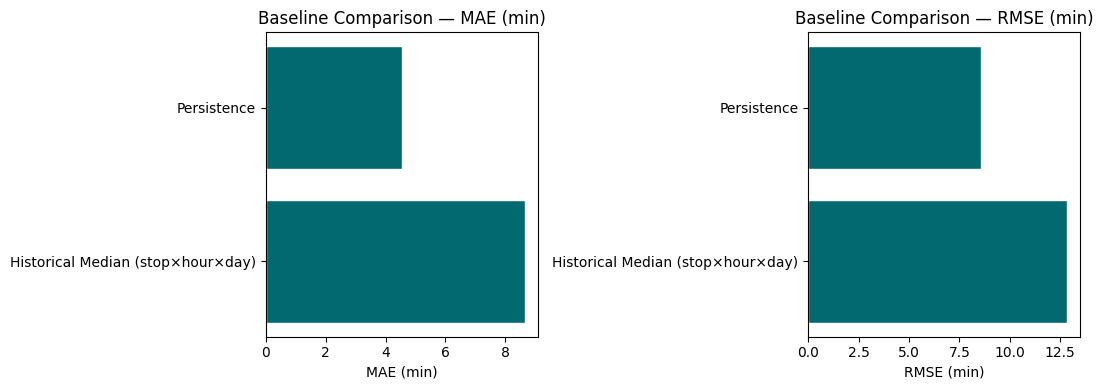

In [114]:
# Cell 12d — Side-by-side comparison of persistence vs historical median

# Persistence metrics (already computed above)
mae_persist  = (df_B41.loc[test_mask, 'delay_minutes'] - df_B41.loc[test_mask, 'pred_persistence']).abs().mean()
rmse_persist = ((df_B41.loc[test_mask, 'delay_minutes'] - df_B41.loc[test_mask, 'pred_persistence'])**2).mean()**0.5

results = pd.DataFrame({
    'Model':      ['Persistence', 'Historical Median (stop×hour×day)'],
    'MAE (min)':  [mae_persist,  mae_hist],
    'RMSE (min)': [rmse_persist, rmse_hist]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['MAE (min)', 'RMSE (min)']):
    ax.barh(results['Model'], results[metric], color='#01696f', edgecolor='white')
    ax.set(xlabel=metric, title=f'Baseline Comparison — {metric}')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_06_baseline_comparison.png', dpi=150)
plt.show()

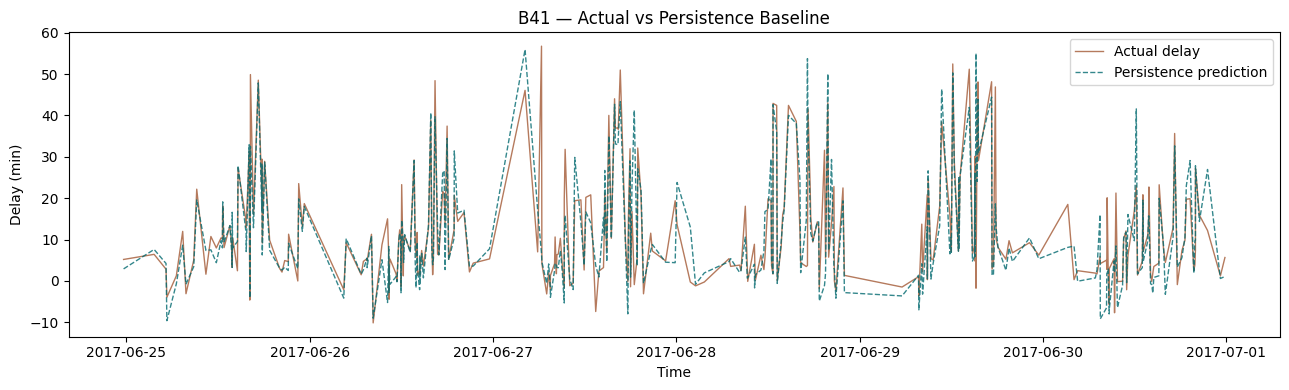

In [115]:
# Cell 12d — Plot actual vs persistence prediction on a test sample
sample = df_B41[test_mask].sample(300, random_state=42).sort_values('Scheduled_dt')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sample['Scheduled_dt'].dt.tz_localize(None),
        sample['delay_minutes'],
        label='Actual delay', color='#964219', alpha=0.7, lw=1)
ax.plot(sample['Scheduled_dt'].dt.tz_localize(None),
        sample['pred_persistence'],
        label='Persistence prediction', color='#01696f', alpha=0.8, lw=1, ls='--')
ax.set(xlabel='Time', ylabel='Delay (min)',
       title='B41 — Actual vs Persistence Baseline')
ax.legend()
plt.tight_layout()
plt.savefig('fig_05_persistence_vs_actual.png', dpi=150)
plt.show()

In [116]:
# Cell 13 — updated: use persistence as point prediction instead of pure noise
# Comment out Option A and use Option B below when ready

# OPTION A — Gaussian noise (original synthetic test)
# np.random.seed(42)
# df_b41['lstm_pred'] = df_b41['delay_minutes'] + np.random.normal(0, 1.5, len(df_b41))

# OPTION B — Persistence baseline
# df_b41['lstm_pred'] = df_b41['pred_persistence']

# OPTION C — Historical median baseline (recommended now)
df_B41['lstm_pred'] = df_B41['pred_hist_median']

# OPTION D — Real LSTM predictions (use when teammates deliver)
# lstm_out = pd.read_csv('lstm_predictions.csv')
# df_B41 = df_B41.merge(lstm_out, left_index=True, right_on='original_index', how='left')

df_B41['residual'] = df_B41['delay_minutes'] - df_B41['lstm_pred']
print(df_B41['residual'].describe())

count    91210.000000
mean         2.437524
std         10.902100
min        -51.300000
25%         -3.700000
50%          0.000000
75%          5.933333
max         61.816667
Name: residual, dtype: float64


In [117]:
# Cell 14 — Build feature matrix and split
from sklearn.model_selection import train_test_split

feature_cols = [
    'lstm_pred',         # primary uncertainty driver
    'DistanceFromStop',  # prediction horizon
    'stop_lat',          # geographic position along B41
    'stop_lon',
    'is_peak',
    'is_weekend',
    'upstream_delay',
]

model_df = df_B41[feature_cols + ['residual', 'delay_minutes']].dropna()

X = model_df[feature_cols]
y = model_df['residual']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (72968, 7)  |  Test: (18242, 7)


In [118]:
# Cell 15 — Train one QR model per target quantile (pinball loss)
import statsmodels.formula.api as smf

train_df = X_train.copy()
train_df['residual'] = y_train.values

QUANTILES = [0.05, 0.10, 0.25, 0.75, 0.90, 0.95]

formula = ('residual ~ lstm_pred + DistanceFromStop + stop_lat + stop_lon'
           ' + is_peak + is_weekend + upstream_delay')

qr_models = {}
for q in QUANTILES:
    m = smf.quantreg(formula, data=train_df).fit(q=q, max_iter=5000)
    qr_models[q] = m
    print(f"Q{int(q*100):02d}  |  Pseudo-R²: {m.prsquared:.4f}")

print("\nAll quantile models trained.")

c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Q05  |  Pseudo-R²: 0.1854


c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Q10  |  Pseudo-R²: 0.1998


c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


...

c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Q75  |  Pseudo-R²: 0.5726


c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Q90  |  Pseudo-R²: 0.6141
Q95  |  Pseudo-R²: 0.5949

All quantile models trained.


c:\Users\billy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [120]:
# Cell 16 — Construct PIs and compute PICP / MPIL
test_df = X_test.copy()
for q in QUANTILES:
    test_df[f'q{int(q*100):02d}'] = qr_models[q].predict(test_df)

test_df['lstm_pred'] = X_test['lstm_pred'].values
test_df['observed']  = model_df.loc[X_test.index, 'delay_minutes'].values

# PI bounds = LSTM point prediction + quantile correction
test_df['pi90_lower'] = test_df['lstm_pred'] + test_df['q05']
test_df['pi90_upper'] = test_df['lstm_pred'] + test_df['q95']
test_df['pi80_lower'] = test_df['lstm_pred'] + test_df['q10']
test_df['pi80_upper'] = test_df['lstm_pred'] + test_df['q90']

# Metrics
def picp(lo, hi, obs): return ((obs >= lo) & (obs <= hi)).mean()
def mpil(lo, hi):      return (hi - lo).mean()

print(f"{'Interval':<10} {'PICP':>8} {'MPIL (min)':>12} {'Status':>8}")
print("-" * 42)
for label, lo, hi in [('80%','pi80_lower','pi80_upper'),
                       ('90%','pi90_lower','pi90_upper')]:
    cov  = picp(test_df[lo], test_df[hi], test_df['observed'])
    ln   = mpil(test_df[lo], test_df[hi])
    flag = '✓ PASS' if cov >= float(label.strip('%'))/100 - 0.03 else '✗ FAIL'
    print(f"{label:<10} {cov:>8.3f} {ln:>12.3f} {flag:>8}")

Interval       PICP   MPIL (min)   Status
------------------------------------------
80%           0.804       13.125   ✓ PASS
90%           0.900       18.115   ✓ PASS


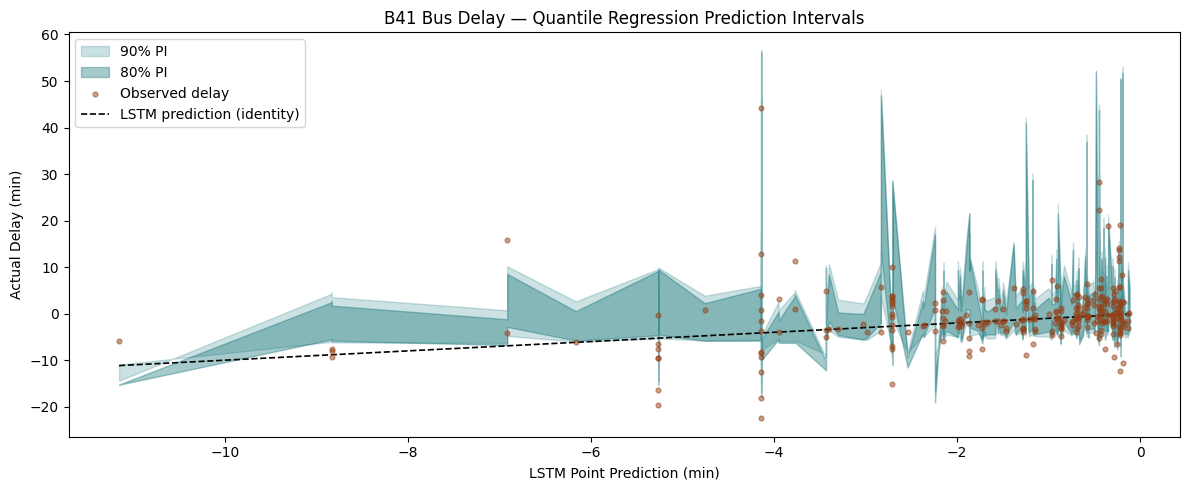

In [121]:
# Cell 17 — Main results plot: PI bands vs LSTM prediction
plot_df = test_df.sort_values('lstm_pred').head(300)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(plot_df['lstm_pred'], plot_df['pi90_lower'], plot_df['pi90_upper'],
                alpha=0.20, color='#01696f', label='90% PI')
ax.fill_between(plot_df['lstm_pred'], plot_df['pi80_lower'], plot_df['pi80_upper'],
                alpha=0.35, color='#01696f', label='80% PI')
ax.scatter(plot_df['lstm_pred'], plot_df['observed'],
           s=12, color='#964219', alpha=0.5, label='Observed delay', zorder=3)
ax.plot(plot_df['lstm_pred'], plot_df['lstm_pred'],
        color='black', lw=1.2, ls='--', label='LSTM prediction (identity)')

ax.set(xlabel='LSTM Point Prediction (min)', ylabel='Actual Delay (min)',
       title='B41 Bus Delay — Quantile Regression Prediction Intervals')
ax.legend()
plt.tight_layout()
plt.savefig('fig_03_prediction_intervals.png', dpi=150)
plt.show()

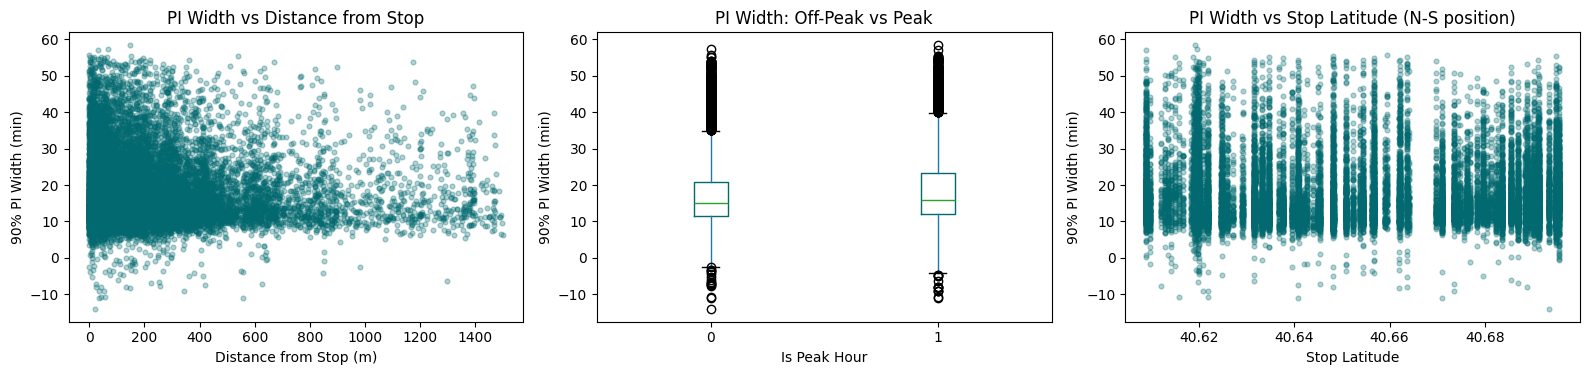

In [122]:
# Cell 18 — Show how uncertainty varies by context (key result)
test_df['pi90_width'] = test_df['pi90_upper'] - test_df['pi90_lower']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Width vs distance from stop
axes[0].scatter(test_df['DistanceFromStop'], test_df['pi90_width'],
                alpha=0.3, s=12, color='#01696f')
axes[0].set(title='PI Width vs Distance from Stop',
            xlabel='Distance from Stop (m)', ylabel='90% PI Width (min)')

# 2. Width by peak / off-peak
test_df.boxplot(column='pi90_width', by='is_peak', ax=axes[1], grid=False,
                boxprops=dict(color='#01696f'))
axes[1].set(title='PI Width: Off-Peak (0) vs Peak (1)',
            xlabel='Is Peak Hour', ylabel='90% PI Width (min)')
plt.sca(axes[1]); plt.title('PI Width: Off-Peak vs Peak')

# 3. Width by stop location (latitude = position along B41 north-south)
axes[2].scatter(test_df['stop_lat'], test_df['pi90_width'],
                alpha=0.3, s=12, color='#01696f')
axes[2].set(title='PI Width vs Stop Latitude (N-S position)',
            xlabel='Stop Latitude', ylabel='90% PI Width (min)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_04_pi_width_context.png', dpi=150)
plt.show()